# 13. Word2Vec на всей цепочке событий

В прошлом опыте мы подавали в Word2Vec пары и тройки событий. Теперь каждая кука идёт в обучение как **одна полная последовательность**: от первого события внутри её суточного окна до последнего. Соседние куки не склеиваем, события после конца окна не берём.

Есть тонкость. Word2Vec учит вектор **типа события**, а не готовый вектор всей куки. Нам всё равно нужно собрать эти векторы в один набор чисел. Простое среднее использует все события, но стирает их порядок. Чтобы проверить порядок, отдельно считаем средние для начала, середины и конца той же цепочки.

## Что сравниваем

- **Средний Word2Vec:** один вектор из всех событий куки. Это прямой ответ на вопрос, помогает ли обучение на полных цепочках.
- **Word2Vec с позициями:** общий вектор плюс три вектора для начала, середины и конца. Такой набор уже отличает, например, поиск в начале от поиска в конце.
- **Доли событий по частям:** тот же порядок, но без Word2Vec. Проверяем, не хватает ли обычных счётчиков.
- **Случайные векторы:** усредняем фиксированные случайные векторы событий такой же размерности. Это контроль на эффект нового представления чисел для CatBoost.

Каждую группу проверяем у одиночной CatBoost и у ансамбля из трёх CatBoost. Настройки моделей не меняем. На каждом из трёх временных отрезков Word2Vec учится только на прошлых куках, после чего оцениваются будущие дни. В среднем векторов нет новой информации по сравнению с долями событий: это просто другое числовое представление тех же частот. Поэтому сравнение со случайными векторами важно.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_full_sequence.py").exists())
os.chdir(root)
sys.path.insert(0, str(root))
from run_full_sequence import main

Признаки считаются в `utils/full_sequence.py`, обучение и проверка в `run_full_sequence.py`. Чтобы пересчитать всё с нуля, поставь `REBUILD = True`.

In [2]:
REBUILD = False
summary_path = root / "output" / "full_sequence_summary.csv"
if REBUILD or not summary_path.exists():
    main()

In [3]:
summary = pd.read_csv(summary_path)
display(summary.style.format({c: "{:.3f}" for c in summary.columns if c != "model"}))

,model,fold_1,fold_2,fold_3,mean_fold,pooled
0,ensemble_full_mean,0.725,0.703,0.800,0.743,0.731
1,random_mean,0.690,0.729,0.757,0.725,0.704
2,current_rank,0.680,0.688,0.806,0.725,0.712
3,full_mean,0.690,0.719,0.758,0.722,0.721
4,ensemble_random_mean,0.676,0.725,0.757,0.719,0.732
5,ensemble_position_shares,0.690,0.692,0.757,0.713,0.686
6,ensemble_full_position,0.619,0.703,0.758,0.693,0.713
7,full_position,0.645,0.692,0.731,0.689,0.711
8,position_shares,0.631,0.685,0.713,0.676,0.690


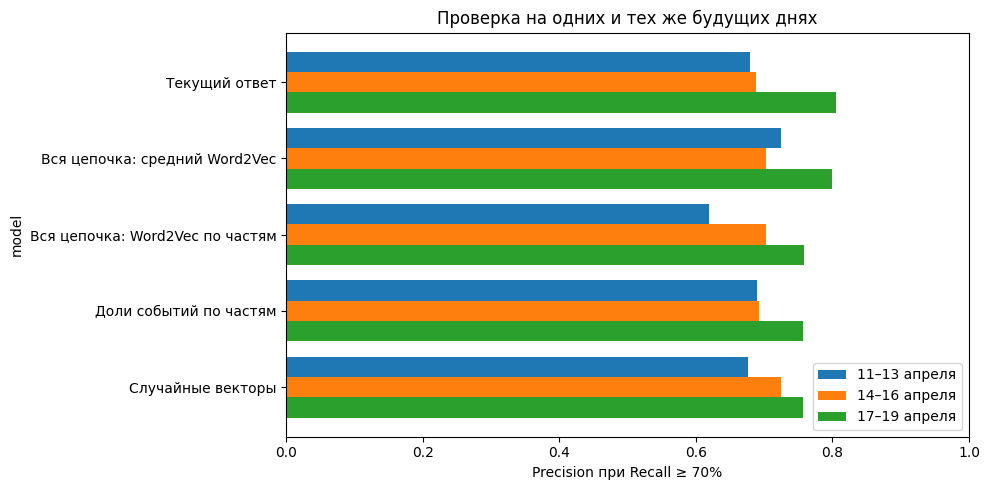

In [4]:
labels = {
    "current_rank": "Текущий ответ",
    "ensemble_full_mean": "Вся цепочка: средний Word2Vec",
    "ensemble_full_position": "Вся цепочка: Word2Vec по частям",
    "ensemble_position_shares": "Доли событий по частям",
    "ensemble_random_mean": "Случайные векторы",
}
shown = summary.set_index("model").loc[list(labels)].rename(index=labels)
ax = shown[["fold_1", "fold_2", "fold_3"]].plot.barh(figsize=(10, 5), width=.8)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_title("Проверка на одних и тех же будущих днях")
ax.legend(["11–13 апреля", "14–16 апреля", "17–19 апреля"], loc="lower right")
plt.tight_layout()
plt.show()

## Результат

Ансамбль со средним Word2Vec по полной последовательности получил **0,743** в среднем по трём отрезкам. У текущего ответа **0,725**, у прошлого Word2Vec по парам **0,737**. По отрезкам новый вариант дал **0,725 / 0,703 / 0,800**, старый ответ **0,680 / 0,688 / 0,806**. Получилось лучше на первых двух отрезках и почти так же на последнем. На всех проверочных куках одной метрикой: **0,731 против 0,712**.

Когда мы добавили отдельные векторы начала, середины и конца, среднее упало до **0,693**. Простые доли событий по этим частям дали **0,713**. Похоже, грубое деление на три участка добавляет шум, особенно для коротких цепочек. Оно не доказало пользу порядка.

Случайные векторы в ансамбле дали **0,719** в среднем, но **0,732** на всех проверочных куках вместе. Значит, часть эффекта может быть связана с тем, как CatBoost использует числовое представление уже известных долей событий. Нельзя честно сказать, что весь прирост создало обучение Word2Vec. Кроме того, мы уже много раз выбирали идеи по этим же дням, так что даже 0,743 может быть оптимистичной оценкой.

## Что с итоговым файлом

Новый вариант пока лежит отдельно в `output/full_sequence_candidate.csv`. Он лучший по **средней метрике на этих трёх временных отрезках**, но результат скрытого теста нам неизвестен. Текущий `output/submission.csv` этот опыт не меняет. Если решим отправлять новый вариант, скрипт воспроизводит файл кандидата из исходных данных и фиксированного seed.

In [5]:
candidate = pd.read_csv(root / "output" / "full_sequence_candidate.csv")
test = pd.read_csv(root / "data" / "test.csv")
assert candidate.columns.tolist() == ["cookie_id", "score"]
assert candidate.cookie_id.equals(test.cookie_id)
assert candidate.score.notna().all() and candidate.score.between(0, 1).all()
print(f"В файле {len(candidate)} кук, пропусков и лишних строк нет")

В файле 4909 кук, пропусков и лишних строк нет
